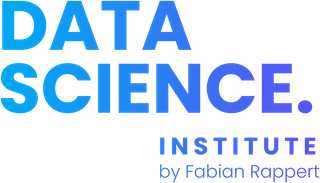

# Inhaltsverzeichnis 

- **Aufgaben zu Requests**
    - **Aufgabe 1**
    - **Aufgabe 2**
    - **Aufgabe 3**
    - **Aufgabe 4**
    - **Aufgabe 5**
    - **Aufgabe 6**


# Aufgaben zu Requests

Gehe auf die Seite https://uselessfacts.jsph.pl/ und versuche zu verstehen, wie die API funktioniert. 

Gib dazu z.B. URLs direkt im Browser ein und schaue dir das Ergebnis an. 

In [ ]:
import requests

## Aufgabe 1

- Schreibe eine Funktion, die einen zufälligen Fakt von der Webseite abfragt. 

In [ ]:
res = requests.get("https://uselessfacts.jsph.pl/api/v2/facts/random")
print(f"{res.json()}")

In [ ]:
def get_random_fact(language: str = "de") -> str:
    url = "https://uselessfacts.jsph.pl/api/v2/facts/random"
    link = f"{url}?language={language}"
    headers = {"Accept": "application/json"}
    res = requests.get(link, headers)
    if res.status_code == 200:
        data = res.json()
        try:
            return data["text"]
        except KeyError:
            return "Fact text not found."
    else:
        return f"Error: {res.status_code}"

In [ ]:
print(get_random_fact())

## Aufgabe 2

- Ergänze obige Funktion, so dass man über einen Parameter bestimmen kann, ob man *deutsche* oder *englische* Fakten erhalten will.

In [ ]:
print(get_random_fact("en"))
print(get_random_fact("de"))

## Aufgabe 3

- Ergänze die Funktion weiter, so dass nur Antworten kommen, die im JSON-Format sind.

In [ ]:
# ich habe das schon gemacht

________________________________________________________________________________  

Benutze im folgenden die [PoetryDB](https://poetrydb.org) um die Aufgaben zu lösen.

## Aufgabe 4

- Wieviel Gedichte hat Emily Dickinson geschrieben?

In [ ]:
def get_poems_by_author(author: str):
    url = f"https://poetrydb.org/author/{author}/title"
    response = requests.get(url)

    if response.status_code == 200:
        poems = response.json()
        print(f"Es gibt {len(poems)} Gedichte von {author}.")
        print()
        print("Diese Gedichte sind:")
        print()
        for poem in poems:
            print(poem["title"])
        return poems
    else:
        return f"Error: {response.status_code}"

In [ ]:
get_poems_by_author("Emily Dickinson")

## Aufgabe 5

- Welches Werk Shakespeares enhält die folgenden Zeilen:

> *The little Love-god lying once asleep,<br>
  Laid by his side his heart-inflaming brand,*   

In [ ]:
def find_title_by_lines(author: str, search_text: str) -> str:
    url = f"https://poetrydb.org/author/{author}/author,title,lines"
    response = requests.get(url)

    if response.status_code == 200:
        poems = response.json()
        found_poems = []

        for poem in poems:
            for line in poem["lines"]:
                if search_text.lower() in line.lower():
                    found_poems.append(poem)
                    break

        if found_poems:
            return [poem["title"] for poem in found_poems]
        else:
            return "No poems found with that text"
    else:
        return f"Error: {response.status_code}"

In [ ]:
find_title_by_lines("William Shakespeare", "The little Love-god lying once asleep")

## Aufgabe 6

Ziel dieser Hausaufgabe ist es, die Grundlagen der API-Paginierung in Python zu verstehen und anzuwenden. Dazu verwenden wir [die größte Sammlung von Open-Source-Hundebildern im Internet](https://dog.ceo/dog-api/).

**Hinweise**:
Da die API keine Rate-Limitierung hat, solltet ihr dennoch respektvoll und verantwortungsbewusst sein, um den Server nicht zu überlasten. **D.h. baue kurze Verzögerung zwischen den API-Anfragen ein**.
Die API-Dokumentation findet ihr [hier](https://github.com/ElliottLandsborough/dog-ceo-api).

Der API-Endpunkt lautet: https://dog.ceo/api/breeds/image/random/

Baut eine Paginierung in euren Python-Code ein, um nur eine bestimmte Anzahl von Hundebildern pro "Seite" zu erhalten. Ihr könnt z.B. 3 Bilder pro Seite als Limit festlegen.

Erstellt eine Schleife in Python, die durch die verschiedenen "Seiten" iteriert und die URLs der Hunde-Bilder für jede Seite ausgibt.

In [ ]:
import time

from IPython.display import Image, display

In [ ]:
# Basis-URL der API
base_url = "https://dog.ceo/api/breeds/image/random/"

# Anzahl der Bilder pro "Seite"
items_per_page = 3

# Anzahl der Seiten, die wir abrufen möchten
num_pages = 5

pause = 1


for page in range(1, num_pages + 1):
    print(f"Page {page}:")
    response = requests.get(f"{base_url}{items_per_page}")

    if response.status_code == 200:
        data = response.json()
        for url in data["message"]:
            print(url)
            display(Image(url, width=200))

    time.sleep(pause)

**Zusätzliche Aufgabe:**
Zeige die Bilder auf der Konsole an. Dafür gibt es viele Lösungen. Eine sehr einfache Möglichkeit: